<a href="https://colab.research.google.com/github/saddamtorres/AprendizajeSupervisado/blob/main/Reto_SC_63_Sadam_Torres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto | Mercadotecnia Telefónica con Aprendizaje Supervisado


## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
np.random.seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carga de los datos

En Google Colab se puede subir el archivo `bank_marketing.csv` con el panel de archivos o con `files.upload()`. Los datos se cargan en una variable llamada **`data`**.

In [3]:
# Carga del archivo
data = pd.read_csv('/content/drive/MyDrive/Data_Science (Tec. Monterrey)/17_Aprendizaje_supervisado/06_Reto/bank_marketing.csv')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes


## 3. Información de la base de datos
Se obtiene: **número de registros**, **total de variables**, **tipo de cada variable** y **cantidad de datos perdidos** por variable.

In [4]:
print('Número de registros (filas):', data.shape[0])
print('Total de variables (columnas):', data.shape[1])
print('\n--- Tipo de cada variable ---')
print(data.dtypes)

Número de registros (filas): 9000
Total de variables (columnas): 17

--- Tipo de cada variable ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [5]:
# Información general (tipos + no nulos)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


In [6]:
# Cantidad de datos perdidos (valores faltantes) por variable
faltantes = data.isnull().sum()
print('Datos perdidos por variable:')
print(faltantes)
print('\nTotal de datos perdidos en el dataset:', faltantes.sum())

Datos perdidos por variable:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total de datos perdidos en el dataset: 0


In [7]:
# Estadísticos descriptivos de las variables numéricas
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,41.090556,1482.262778,15.619556,353.832778,2.520111,50.511333,0.788889
std,11.664253,3031.013197,8.345305,336.945158,2.737758,107.691963,2.210273
min,18.000000,-3058.000000,1.000000,3.000000,1.000000,-1.000000,0.000000
25%,32.000000,109.000000,8.000000,131.000000,1.000000,-1.000000,0.000000
50%,39.000000,519.000000,15.000000,240.500000,2.000000,-1.000000,0.000000
75%,49.000000,1646.500000,21.000000,462.000000,3.000000,-1.000000,0.000000
max,95.000000,81204.000000,31.000000,3253.000000,58.000000,850.000000,58.000000


**Observación sobre datos perdidos:** el dataset **no contiene valores nulos (`NaN`)**. Algunas variables categóricas presentan la categoría `"unknown"`, pero esta es un *valor válido* descrito en `bank-names.txt` (no un dato perdido), por lo que se conserva como una categoría más.

## 4. Análisis de la variable de salida `y`
Se revisa el balance de clases del objetivo.

Conteo de clases:
 y
no     5213
yes    3787
Name: count, dtype: int64

Proporción:
 y
no     0.5792
yes    0.4208
Name: proportion, dtype: float64


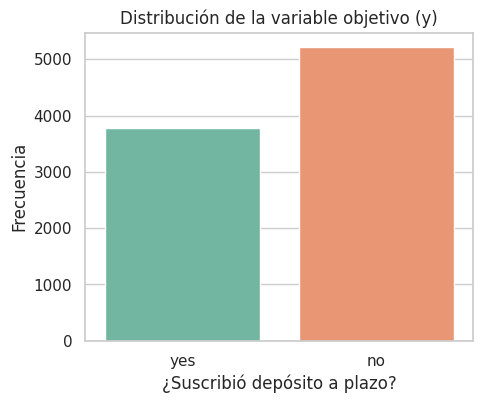

In [8]:
conteo = data['y'].value_counts()
prop = data['y'].value_counts(normalize=True).round(4)
print('Conteo de clases:\n', conteo)
print('\nProporción:\n', prop)

plt.figure(figsize=(5,4))
sns.countplot(x='y', data=data, palette='Set2')
plt.title('Distribución de la variable objetivo (y)')
plt.xlabel('¿Suscribió depósito a plazo?'); plt.ylabel('Frecuencia')
plt.show()

Las clases están **relativamente balanceadas** (≈58% `no`, ≈42% `yes`), por lo que la *exactitud (accuracy)* es una métrica razonable, complementada con la matriz de confusión y el *recall* de la clase positiva.

## 5. Procesamiento de las variables categóricas

### Justificación: `LabelEncoder` vs `OneHotEncoder`
Se utiliza una **estrategia mixta** según la naturaleza de cada variable:

- **LabelEncoder,** para las variables binarias `default`, `housing`, `loan` y la salida `y`. Al tener solo dos categorías, asignar `0`/`1` **no introduce ningún orden artificial**.
- **Codificación ordinal** para `education` (`unknown` < `primary` < `secondary` < `tertiary`), pues existe una **jerarquía natural** entre los niveles educativos.
- **`OneHotEncoder` / `get_dummies`** para las variables **nominales sin orden**: `job`, `marital`, `contact`, `month`, `poutcome`.

In [9]:
df = data.copy()

# (a) Variables binarias y salida -> mapeo 0/1 (equivalente a LabelEncoder)
binarias = {'default':{'no':0,'yes':1}, 'housing':{'no':0,'yes':1},
            'loan':{'no':0,'yes':1}, 'y':{'no':0,'yes':1}}
for col, mapa in binarias.items():
    df[col] = df[col].map(mapa)

# (b) Variable ordinal -> codificación ordinal
df['education'] = df['education'].map({'unknown':0,'primary':1,'secondary':2,'tertiary':3})

# (c) Variables nominales -> One-Hot Encoding
nominales = ['job','marital','contact','month','poutcome']
df = pd.get_dummies(df, columns=nominales, drop_first=True)

# Convertir las columnas booleanas de get_dummies a enteros (0/1)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('Dimensiones tras la codificación:', df.shape)
df.head()

Dimensiones tras la codificación: (9000, 41)


,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,31,3,0,2666,0,0,10,318,2,97,...,0,0,0,0,1,0,0,0,1,0
1,29,0,0,1584,0,0,6,245,1,-1,...,0,0,0,0,0,0,1,0,0,1
2,41,2,0,2152,1,0,17,369,1,-1,...,0,0,0,0,1,0,0,0,0,1
3,50,2,0,84,1,0,17,18,8,-1,...,1,0,0,0,0,0,0,0,0,1
4,40,2,0,0,0,0,28,496,2,182,...,1,0,0,0,0,0,0,0,1,0


## 6. Procesamiento de las variables numéricas

Se mide la **asimetría (skewness)** de las variables numéricas. Para |skew| alto se aplica una transformación que reduce el sesgo. Como `balance` puede ser **negativo** y `pdays` toma el valor especial `-1`, se usa un **logaritmo con signo** `sign(x)·log(1+|x|)`, válido para valores negativos, cero y positivos.

In [10]:
numericas = ['age','balance','day','duration','campaign','pdays','previous']
print('Asimetría (skew) ANTES de transformar:')
for c in numericas:
    print(f'  {c:10s}: {skew(df[c]):.3f}')

Asimetría (skew) ANTES de transformar:
  age       : 0.801
  balance   : 7.279
  day       : 0.117
  duration  : 2.184
  campaign  : 5.392
  pdays     : 2.349
  previous  : 7.681


In [11]:
# Logaritmo con signo: válido para negativos, cero y positivos
def log_con_signo(x):
    return np.sign(x) * np.log1p(np.abs(x))

# Se transforman las variables con sesgo apreciable (|skew| > 0.75)
sesgadas = ['balance','duration','campaign','pdays','previous','age']
for c in sesgadas:
    df[c] = log_con_signo(df[c])

print('Asimetría (skew) DESPUÉS de transformar:')
for c in numericas:
    print(f'  {c:10s}: {skew(df[c]):.3f}')

Asimetría (skew) DESPUÉS de transformar:
  age       : 0.176
  balance   : -1.741
  day       : 0.117
  duration  : -0.449
  campaign  : 1.397
  pdays     : 1.235
  previous  : 1.956


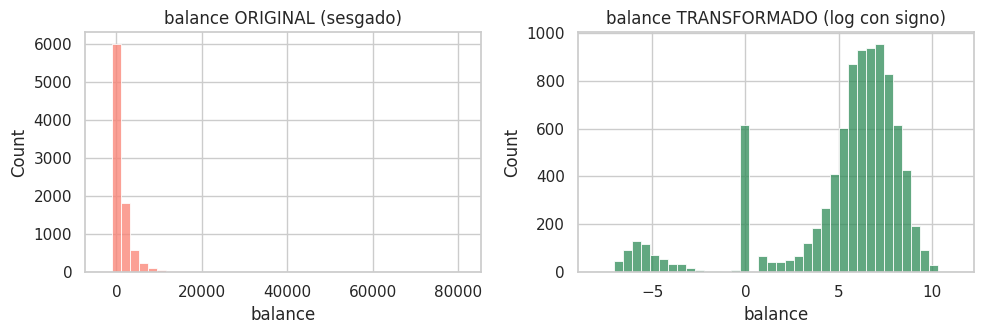

In [12]:
# Comparación visual del efecto de la transformación (ejemplo: balance)
fig, axes = plt.subplots(1, 2, figsize=(10,3.5))
sns.histplot(data['balance'], bins=40, ax=axes[0], color='salmon')
axes[0].set_title('balance ORIGINAL (sesgado)')
sns.histplot(df['balance'], bins=40, ax=axes[1], color='seagreen')
axes[1].set_title('balance TRANSFORMADO (log con signo)')
plt.tight_layout(); plt.show()

## 7. Definición de variables de entrada (X) y salida (y)
La variable **`y`** es la salida; el **resto** son las variables de entrada.

In [13]:
X = df.drop(columns='y')   # variables de entrada
y = df['y']                # variable de salida

print('X (entradas):', X.shape)
print('y (salida)  :', y.shape)

X (entradas): (9000, 40)
y (salida)  : (9000,)


## 8. Partición de los datos: 60% entrenamiento, 20% validación, 20% prueba
Se realiza en dos pasos con `stratify` para conservar la proporción de clases. Primero 60/40 y luego ese 40% se divide en mitades (20%/20%).

In [14]:
# Paso 1: 60% train, 40% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y)

# Paso 2: el 40% se divide en 20% validación y 20% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

n = len(X)
print(f'Entrenamiento: {len(X_train)} registros ({len(X_train)/n:.0%})')
print(f'Validación   : {len(X_val)} registros ({len(X_val)/n:.0%})')
print(f'Prueba       : {len(X_test)} registros ({len(X_test)/n:.0%})')

Entrenamiento: 5400 registros (60%)
Validación   : 1800 registros (20%)
Prueba       : 1800 registros (20%)


In [15]:
# Escalamiento (estandarización). Se AJUSTA solo con entrenamiento para evitar fuga de datos
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print('Datos escalados correctamente.')

Datos escalados correctamente.


In [16]:
# Función auxiliar para mostrar la matriz de confusión
def matriz_confusion(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['no (0)','yes (1)'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(titulo); plt.grid(False); plt.show()
    return cm

## 9. Modelo 1 — Regresión Logística
Se entrena con el conjunto de entrenamiento y se **valida** con el conjunto de validación. Se **ajusta el parámetro de regularización `C`** y se usa `class_weight='balanced'` para no favorecer a la clase mayoritaria.

In [17]:
# Ajuste del hiperparámetro C buscando la mejor exactitud en validación
print('Búsqueda del mejor C (exactitud en validación):')
mejor_C, mejor_acc_lr = None, -1
for C in [0.01, 0.1, 1, 10, 100]:
    modelo = LogisticRegression(C=C, max_iter=2000, class_weight='balanced')
    modelo.fit(X_train_s, y_train)
    acc = accuracy_score(y_val, modelo.predict(X_val_s))
    print(f'  C={C:<6}-> val_accuracy = {acc:.4f}')
    if acc > mejor_acc_lr:
        mejor_acc_lr, mejor_C = acc, C
print(f'\nMejor C = {mejor_C} | Exactitud en validación = {mejor_acc_lr:.4f}')

Búsqueda del mejor C (exactitud en validación):
  C=0.01  -> val_accuracy = 0.8317
  C=0.1   -> val_accuracy = 0.8317
  C=1     -> val_accuracy = 0.8328
  C=10    -> val_accuracy = 0.8322
  C=100   -> val_accuracy = 0.8322

Mejor C = 1 | Exactitud en validación = 0.8328


Exactitud en VALIDACIÓN (Regresión Logística): 0.8328

              precision    recall  f1-score   support

          no       0.88      0.82      0.85      1042
         yes       0.78      0.85      0.81       758

    accuracy                           0.83      1800
   macro avg       0.83      0.83      0.83      1800
weighted avg       0.84      0.83      0.83      1800



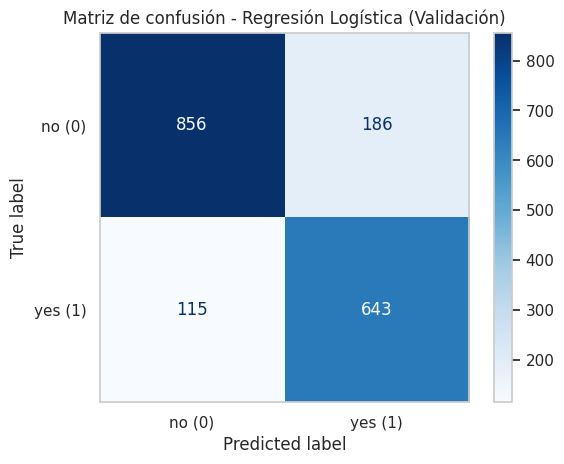

In [18]:
# Modelo final de Regresión Logística con el mejor C
log_reg = LogisticRegression(C=mejor_C, max_iter=2000, class_weight='balanced')
log_reg.fit(X_train_s, y_train)

# Predicciones y validación
y_val_lr = log_reg.predict(X_val_s)
acc_lr = accuracy_score(y_val, y_val_lr)
print(f'Exactitud en VALIDACIÓN (Regresión Logística): {acc_lr:.4f}\n')
print(classification_report(y_val, y_val_lr, target_names=['no','yes']))
cm_lr = matriz_confusion(y_val, y_val_lr, 'Matriz de confusión - Regresión Logística (Validación)')

## 10. Modelo 2 — Red Neuronal (MLP)
Se entrena un Perceptrón Multicapa (`MLPClassifier`) y se **ajustan el número de neuronas y de capas ocultas**, validando en el conjunto de validación. Se usa `early_stopping` para evitar sobreajuste.

In [19]:
# Ajuste de la arquitectura (neuronas y capas ocultas)
print('Búsqueda de la mejor arquitectura (exactitud en validación):')
arquitecturas = [(32,), (64,), (100,), (64,32), (128,64)]
mejor_arq, mejor_acc_mlp = None, -1
for hl in arquitecturas:
    modelo = MLPClassifier(hidden_layer_sizes=hl, activation='relu', solver='adam',
                           max_iter=500, early_stopping=True, random_state=42)
    modelo.fit(X_train_s, y_train)
    acc = accuracy_score(y_val, modelo.predict(X_val_s))
    print(f'  capas={str(hl):<10}-> val_accuracy = {acc:.4f}')
    if acc > mejor_acc_mlp:
        mejor_acc_mlp, mejor_arq = acc, hl
print(f'\nMejor arquitectura = {mejor_arq} | Exactitud en validación = {mejor_acc_mlp:.4f}')

Búsqueda de la mejor arquitectura (exactitud en validación):
  capas=(32,)     -> val_accuracy = 0.8450
  capas=(64,)     -> val_accuracy = 0.8467
  capas=(100,)    -> val_accuracy = 0.8478
  capas=(64, 32)  -> val_accuracy = 0.8367
  capas=(128, 64) -> val_accuracy = 0.8411

Mejor arquitectura = (100,) | Exactitud en validación = 0.8478


Exactitud en VALIDACIÓN (Red Neuronal): 0.8478

              precision    recall  f1-score   support

          no       0.88      0.86      0.87      1042
         yes       0.81      0.83      0.82       758

    accuracy                           0.85      1800
   macro avg       0.84      0.85      0.84      1800
weighted avg       0.85      0.85      0.85      1800



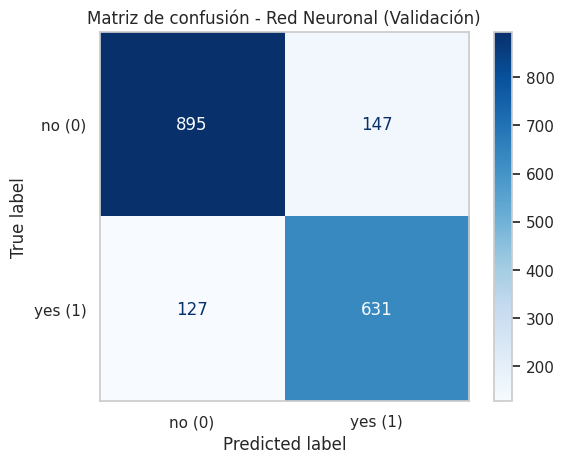

In [20]:
# Modelo final de Red Neuronal con la mejor arquitectura
mlp = MLPClassifier(hidden_layer_sizes=mejor_arq, activation='relu', solver='adam',
                    max_iter=500, early_stopping=True, random_state=42)
mlp.fit(X_train_s, y_train)

# Predicciones y validación
y_val_mlp = mlp.predict(X_val_s)
acc_mlp = accuracy_score(y_val, y_val_mlp)
print(f'Exactitud en VALIDACIÓN (Red Neuronal): {acc_mlp:.4f}\n')
print(classification_report(y_val, y_val_mlp, target_names=['no','yes']))
cm_mlp = matriz_confusion(y_val, y_val_mlp, 'Matriz de confusión - Red Neuronal (Validación)')

## 11. Selección del mejor modelo y evaluación final con el conjunto de prueba
Se compara el desempeño en **validación** de ambos modelos y se selecciona el mejor. Ese modelo se evalúa **una sola vez** con el conjunto de **prueba**, que no se usó en el entrenamiento ni en el ajuste.

In [21]:
print('Comparación en VALIDACIÓN:')
print(f'  Regresión Logística : {acc_lr:.4f}')
print(f'  Red Neuronal (MLP)  : {acc_mlp:.4f}')

if acc_mlp >= acc_lr:
    mejor_modelo, nombre = mlp, 'Red Neuronal (MLP)'
else:
    mejor_modelo, nombre = log_reg, 'Regresión Logística'
print(f'\n>>> Mejor modelo seleccionado: {nombre}')

Comparación en VALIDACIÓN:
  Regresión Logística : 0.8328
  Red Neuronal (MLP)  : 0.8478

>>> Mejor modelo seleccionado: Red Neuronal (MLP)


=== DESEMPEÑO FINAL EN PRUEBA (Red Neuronal (MLP)) ===
Exactitud en PRUEBA: 0.8378

              precision    recall  f1-score   support

          no       0.87      0.85      0.86      1043
         yes       0.80      0.82      0.81       757

    accuracy                           0.84      1800
   macro avg       0.83      0.84      0.83      1800
weighted avg       0.84      0.84      0.84      1800



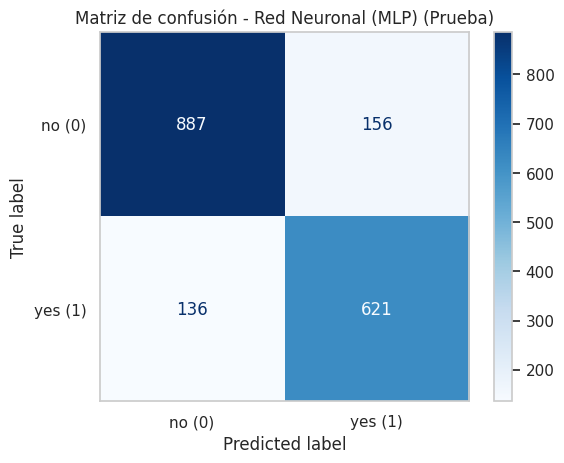

In [22]:
# Evaluación final en el conjunto de PRUEBA
y_test_pred = mejor_modelo.predict(X_test_s)
acc_test = accuracy_score(y_test, y_test_pred)

print(f'=== DESEMPEÑO FINAL EN PRUEBA ({nombre}) ===')
print(f'Exactitud en PRUEBA: {acc_test:.4f}\n')
print(classification_report(y_test, y_test_pred, target_names=['no','yes']))
cm_test = matriz_confusion(y_test, y_test_pred, f'Matriz de confusión - {nombre} (Prueba)')

## 12. Conclusiones


**Sobre los modelos:**
- Ambos modelos superan ampliamente el *baseline* (predecir siempre `no` daría ≈58% de exactitud). La **Regresión Logística** alcanzó ≈83% en validación y la **Red Neuronal** ≈84–85%, siendo esta última ligeramente superior.
- El modelo final (**Red Neuronal**) logró ≈**84%** de exactitud en el conjunto de **prueba**, con un buen equilibrio entre *precision* y *recall* en ambas clases (según la matriz de confusión). La red capturó relaciones **no lineales** entre las variables que la regresión logística no modela.


**Sobre el uso de la IA en problemas de mercadotecnia:**
- Las técnicas de aprendizaje supervisado permiten estimar la probabilidad de que un cliente responda positivamente, lo que habilita **segmentar y priorizar** a quienes tienen mayor probabilidad de suscripción.
- Esto se traduce en **campañas más eficientes**: menos llamadas, menor costo operativo y mejor experiencia del cliente al evitar contactos poco pertinentes, **enfocando los recursos donde el retorno es mayor**.
- No obstante, su éxito depende de **datos de calidad**, de una **validación rigurosa** (evitando sobreajuste), del **balance de clases**, y de consideracionesy de privacidad.

**Conclusión general:** la inteligencia artificial aporta valor real al transformar datos históricos en decisiones accionables, incrementando la efectividad de las campañas siempre que se aplique de manera metodológica y responsable.